## Import Libs

In [34]:
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Load Data

In [35]:
def load_data(path):
    try:
        df = pd.read_csv(path)
        print(f'Data is loaded with : {len(df)} Rows')
        print(f"Shape Data : {df.shape}")
        return df
    except Exception as e:
        print(f'You have a problem: {e}')
        return None

path = "../../data/raw/Clean_2.csv"
df = load_data(path)

Data is loaded with : 672 Rows
Shape Data : (672, 11)


In [36]:
cat_columns = ['job_clean_encoded','size_encoded', 'sector_encoded', 'industry_encoded', 'state_encoded']
num_columns = ['company_age', 'skills_count', 'desc_length', 'title_length']
target = ['salary_clean']

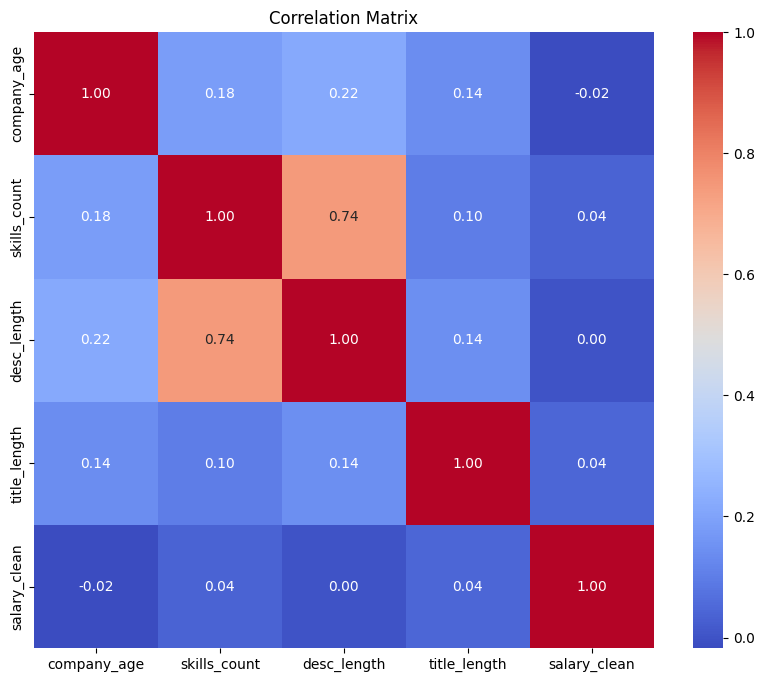

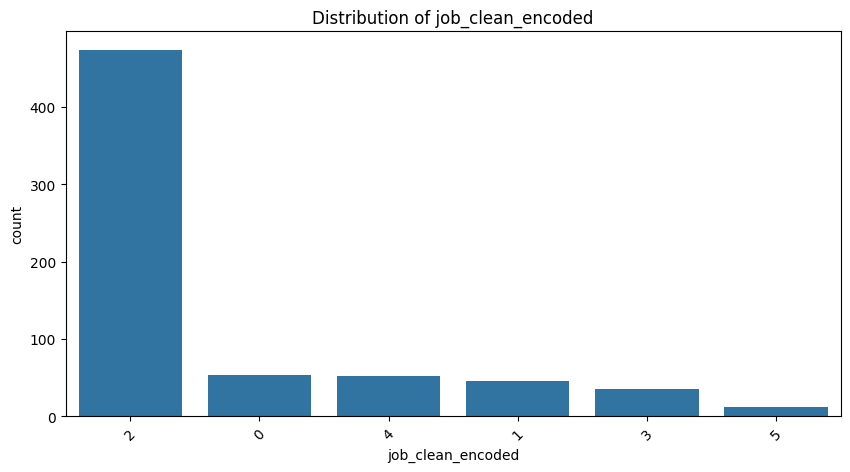

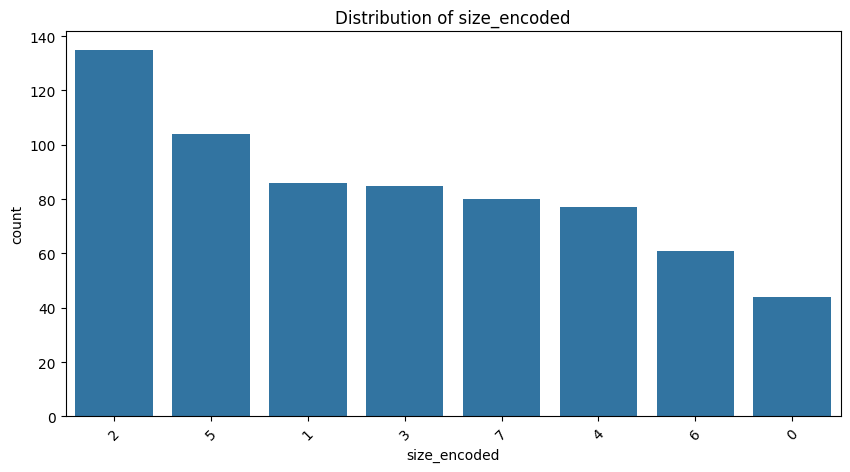

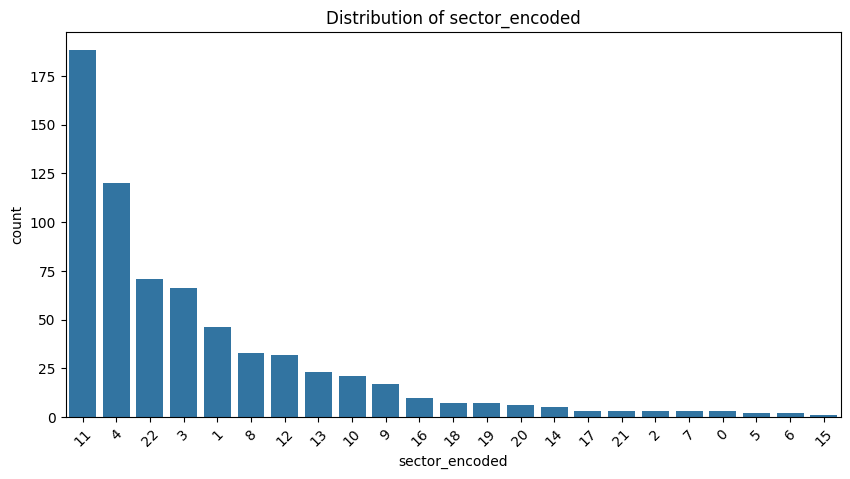

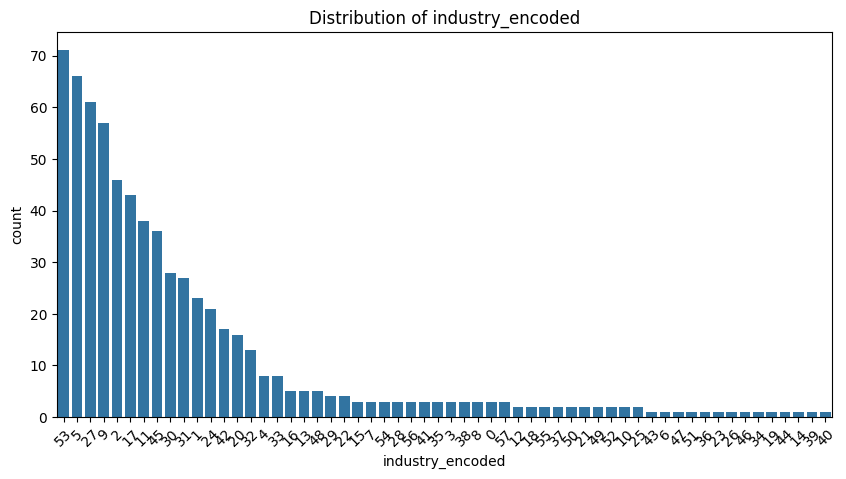

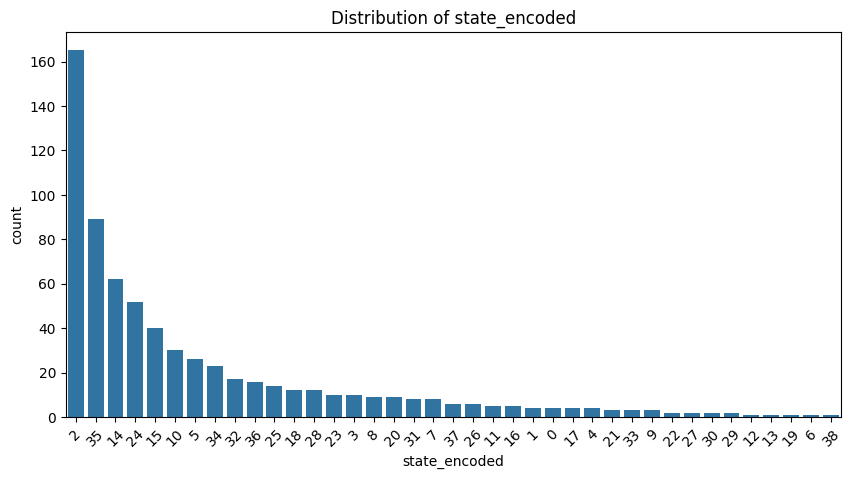

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap for numerical columns and target
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_columns + target].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Count plots for categorical columns
for col in cat_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [38]:
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import StandardScaler

# Features
feature_cols = [
    'Rating', 'company_age', 'skills_count', 'desc_length', 'title_length',
    'job_clean_encoded', 'size_encoded', 'sector_encoded', 'industry_encoded', 'state_encoded'
]

# Remove salary outliers
z_scores = np.abs((df['salary_clean'] - df['salary_clean'].mean()) / df['salary_clean'].std())
df_clean = df[z_scores < 3]




scaler = StandardScaler()
df_clean[num_columns] = scaler.fit_transform(df_clean[num_columns])


X = df_clean[feature_cols]
y = df_clean['salary_clean']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# GridSearch
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Use best model
model = grid.best_estimator_

print("Best parameters:", grid.best_params_)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
MAE: 21534.09
R2 Score: -0.0045
